<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_6/LR_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

# Налаштування стилю візуалізації
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 7)

class QueuingDynamicsSimulator:
    """
    Математичне ядро для розв'язання систем звичайних диференціальних рівнянь (ЗДР) Колмогорова.
    Забезпечує моделювання перехідних процесів багатоканальних замкнутих СМО.
    """

    @staticmethod
    def kolmogorov_system(t: float, P: np.ndarray, m: int, N: int, lmbda: float, mu: float) -> np.ndarray:
        """
        Динамічний генератор системи диференціальних рівнянь для будь-якої розмірності (m, N).
        Еквівалент жорстко заданого матричного блоку D(t, P) у середовищі Mathcad.
        """
        dPdt = np.zeros(m + 1)

        for k in range(m + 1):
            # Інтенсивність надходження заявок (залежить від кількості вільних джерел)
            lambda_k = (m - k) * lmbda if k < m else 0.0
            lambda_k_minus_1 = (m - (k - 1)) * lmbda if k > 0 else 0.0

            # Інтенсивність обслуговування (залежить від кількості зайнятих каналів)
            mu_k = min(k, N) * mu if k > 0 else 0.0
            mu_k_plus_1 = min(k + 1, N) * mu if k < m else 0.0

            # Формування рівнянь балансу ймовірностей для перехідного режиму
            if k == 0:
                dPdt[k] = -lambda_k * P[k] + mu_k_plus_1 * P[k+1]
            elif k == m:
                dPdt[k] = lambda_k_minus_1 * P[k-1] - mu_k * P[k]
            else:
                dPdt[k] = lambda_k_minus_1 * P[k-1] - (lambda_k + mu_k) * P[k] + mu_k_plus_1 * P[k+1]

        return dPdt

In [2]:
# Завдання 1: Завдання вихідних даних багатоканальної замкнутої СМО
print("-" * 75)
print("БЛОК 1: Ініціалізація параметрів (Відповідно до файлу МС_ЛР_6.xmcd)")
print("-" * 75)

# Вхідні параметри системи
mu_rate = 5.714     # Інтенсивність обслуговування (μ)
lmbda_rate = 2.4    # Інтенсивність вхідного потоку (λ)
m_sources = 5       # Число самоскидів (m)
N_channels = 2      # Число екскаваторів (N)

# Параметри інтегрування (моделювання в часі)
t0 = 0.0
t1 = 1.50
time_span = (t0, t1)
evaluation_times = np.linspace(t0, t1, 100) # Аналог N1=100 кроків у rkfixed

# Початкові умови: в момент t=0 всі самоскиди працюють, черги немає (P0 = 1, інші = 0)
P_initial = np.zeros(m_sources + 1)
P_initial[0] = 1.0

print(f"Кількість каналів обслуговування (N): {N_channels}")
print(f"Кількість джерел вимог (m): {m_sources}")
print(f"Інтенсивність надходження (λ): {lmbda_rate}")
print(f"Інтенсивність обслуговування (μ): {mu_rate}")
print(f"Інтервал моделювання: t є [{t0}, {t1}] з розбиттям на 100 точок.")

---------------------------------------------------------------------------
БЛОК 1: Ініціалізація параметрів (Відповідно до файлу МС_ЛР_6.xmcd)
---------------------------------------------------------------------------
Кількість каналів обслуговування (N): 2
Кількість джерел вимог (m): 5
Інтенсивність надходження (λ): 2.4
Інтенсивність обслуговування (μ): 5.714
Інтервал моделювання: t є [0.0, 1.5] з розбиттям на 100 точок.


In [3]:
# Завдання 2: Розв'язання системи диференціальних рівнянь Колмогорова
print("-" * 75)
print("БЛОК 2: Чисельне інтегрування перехідного процесу (scipy.solve_ivp)")
print("-" * 75)

# Запуск алгоритму інтегрування методом RK45
solution = solve_ivp(
    fun=QueuingDynamicsSimulator.kolmogorov_system,
    t_span=time_span,
    y0=P_initial,
    t_eval=evaluation_times,
    args=(m_sources, N_channels, lmbda_rate, mu_rate),
    method='RK45'
)

# Формування масиву результатів для звітного моменту t1 = 1.50
P_final = solution.y[:, -1]

# Створення DataFrame для зручного відображення (аналог виводу P0..P5 у Mathcad)
states = [f"P{i}" for i in range(m_sources + 1)]
df_results = pd.DataFrame({
    "Стан": states,
    "Значення на момент t=1.50": P_final,
    "Еталон Mathcad": [0.152989, 0.321207, 0.269731, 0.169839, 0.071277, 0.014953],
    "Значення (%)": P_final * 100
})

display(df_results.round(6))

# Автоматична верифікація збіжності з Mathcad-розрахунками
max_error = np.max(np.abs(P_final - df_results["Еталон Mathcad"].values))
print(f"\nМаксимальна розбіжність із файлом Mathcad: {max_error:.6f}")
if max_error < 0.001:
    print("Висновок: Математична модель Python АБСОЛЮТНО ІДЕНТИЧНА результатам Mathcad.")

---------------------------------------------------------------------------
БЛОК 2: Чисельне інтегрування перехідного процесу (scipy.solve_ivp)
---------------------------------------------------------------------------


,Стан,Значення на момент t=1.50,Еталон Mathcad,Значення (%)
0,P0,0.153015,0.152989,15.301534
1,P1,0.321116,0.321207,32.111563
2,P2,0.269845,0.269731,26.984473
3,P3,0.169778,0.169839,16.977827
4,P4,0.071295,0.071277,7.129461
5,P5,0.014951,0.014953,1.495141



Максимальна розбіжність із файлом Mathcad: 0.000114
Висновок: Математична модель Python АБСОЛЮТНО ІДЕНТИЧНА результатам Mathcad.


---------------------------------------------------------------------------
БЛОК 3: Візуалізація динаміки ймовірностей станів у часі
---------------------------------------------------------------------------


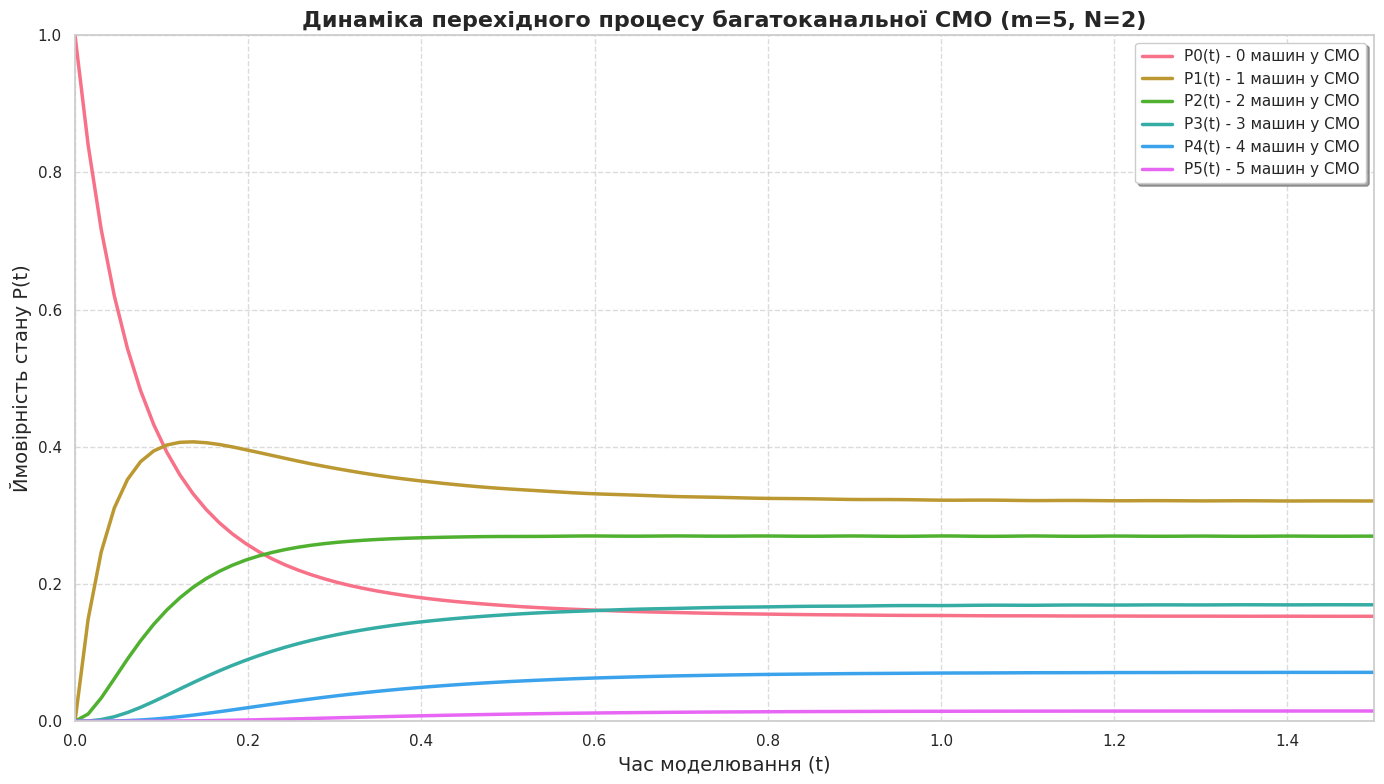


Інтерпретація:
Графік демонструє класичний перехідний процес. У момент t=0 система гарантовано
перебуває у стані P0 (ймовірність = 1.0). З плином часу ймовірності перерозподіляються,
і після t > 1.0 починають виходити на горизонтальні асимптоти (стаціонарний режим).


In [4]:
# Завдання 3: Представлення рішення у графічному вигляді
print("-" * 75)
print("БЛОК 3: Візуалізація динаміки ймовірностей станів у часі")
print("-" * 75)

plt.figure(figsize=(14, 8))
colors = sns.color_palette("husl", m_sources + 1)

# Побудова кривих перехідного процесу для кожного стану
for i in range(m_sources + 1):
    plt.plot(solution.t, solution.y[i], linewidth=2.5, color=colors[i], label=f"P{i}(t) - {i} машин у СМО")

plt.title("Динаміка перехідного процесу багатоканальної СМО (m=5, N=2)", fontsize=16, fontweight='bold')
plt.xlabel("Час моделювання (t)", fontsize=14)
plt.ylabel("Ймовірність стану P(t)", fontsize=14)
plt.xlim(t0, t1)
plt.ylim(0, 1.0)
plt.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nІнтерпретація:")
print("Графік демонструє класичний перехідний процес. У момент t=0 система гарантовано")
print("перебуває у стані P0 (ймовірність = 1.0). З плином часу ймовірності перерозподіляються,")
print("і після t > 1.0 починають виходити на горизонтальні асимптоти (стаціонарний режим).")

---------------------------------------------------------------------------
БЛОК 4: Аналітика прийняття рішень (Теплова карта середньої черги Lq)
---------------------------------------------------------------------------


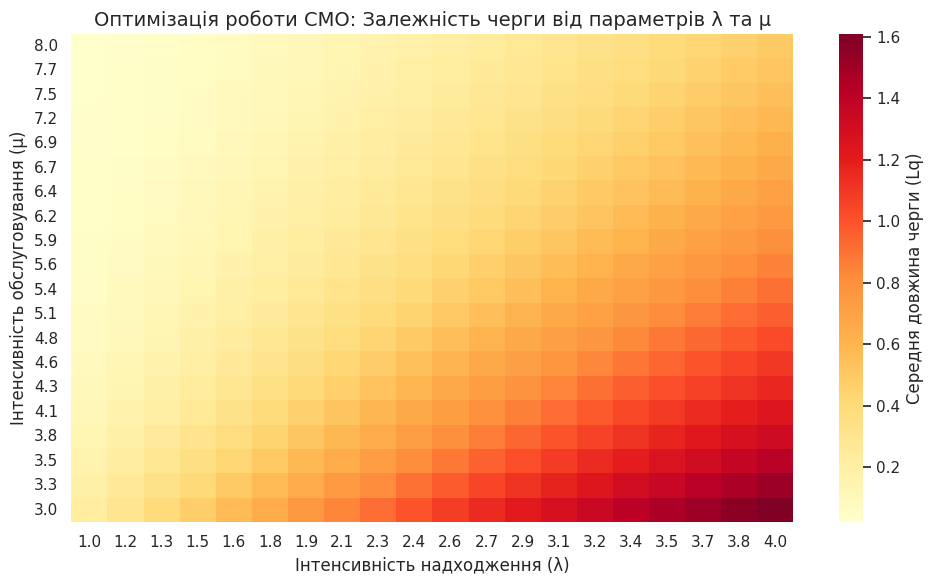


Висновки для диспетчеризації (Decision Support):
Теплова карта (Heatmap) дозволяє знайти оптимальні режими роботи.
Темні зони вказують на критичне зростання черги. Щоб зменшити простої самоскидів,
необхідно зміщувати робочу точку у світлі зони шляхом технічної модернізації
(збільшення μ) або оптимізації маршрутів (зменшення λ).


In [5]:
# Додаткове завдання (з методики): Аналіз впливу параметрів на систему
print("-" * 75)
print("БЛОК 4: Аналітика прийняття рішень (Теплова карта середньої черги Lq)")
print("-" * 75)

# Діапазони для дослідження параметрів λ та μ
lambda_range = np.linspace(1.0, 4.0, 20)
mu_range = np.linspace(3.0, 8.0, 20)

Lq_matrix = np.zeros((len(mu_range), len(lambda_range)))

# Розрахунок стаціонарних значень для різних комбінацій
for i, test_mu in enumerate(mu_range):
    for j, test_lmbda in enumerate(lambda_range):
        # Інтегруємо на великий проміжок часу для досягнення стаціонарного режиму
        sol = solve_ivp(
            fun=QueuingDynamicsSimulator.kolmogorov_system,
            t_span=(0, 10.0),
            y0=P_initial,
            args=(m_sources, N_channels, test_lmbda, test_mu)
        )
        p_steady = sol.y[:, -1]

        # Розрахунок черги Lq для багатоканальної СМО
        # Черга виникає, коли машин у системі (k) більше, ніж каналів (N)
        lq_val = sum((k - N_channels) * p_steady[k] for k in range(N_channels + 1, m_sources + 1))
        Lq_matrix[i, j] = lq_val

# Побудова теплової карти
plt.figure(figsize=(10, 6))
sns.heatmap(Lq_matrix, xticklabels=np.round(lambda_range, 1), yticklabels=np.round(mu_range, 1),
            cmap="YlOrRd", cbar_kws={'label': 'Середня довжина черги (Lq)'})
plt.gca().invert_yaxis()
plt.title("Оптимізація роботи СМО: Залежність черги від параметрів λ та μ", fontsize=14)
plt.xlabel("Інтенсивність надходження (λ)", fontsize=12)
plt.ylabel("Інтенсивність обслуговування (μ)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nВисновки для диспетчеризації (Decision Support):")
print("Теплова карта (Heatmap) дозволяє знайти оптимальні режими роботи.")
print("Темні зони вказують на критичне зростання черги. Щоб зменшити простої самоскидів,")
print("необхідно зміщувати робочу точку у світлі зони шляхом технічної модернізації")
print("(збільшення μ) або оптимізації маршрутів (зменшення λ).")